# Trực quan hóa dữ liệu & Phân tích Cường độ Pixel

Notebook này tập trung vào việc quan sát sâu hơn các đặc điểm trực quan của khuôn mặt và phân tích thống kê giá trị pixel. Kết quả từ notebook này sẽ trực tiếp hỗ trợ việc thiết lập các phép chuẩn hóa (Normalization) trong pipeline huấn luyện.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tqdm import tqdm

# Thiết lập thẩm mỹ
sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = (12, 6)

EMOTIONS_MAP = {
    0: 'Angry', 
    1: 'Disgust', 
    2: 'Fear', 
    3: 'Happy', 
    4: 'Sad', 
    5: 'Surprise', 
    6: 'Neutral'
}

DATA_DIR = "../../data/fer_data/"
df_train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))

## 1. Lưới ảnh mẫu (Sample Grids - 5x5)
Chúng ta sẽ hiển thị 25 ảnh mẫu cho mỗi loại cảm xúc để thấy được sự đa dạng về góc mặt, độ tuổi và điều kiện ánh sáng trong FER2013.

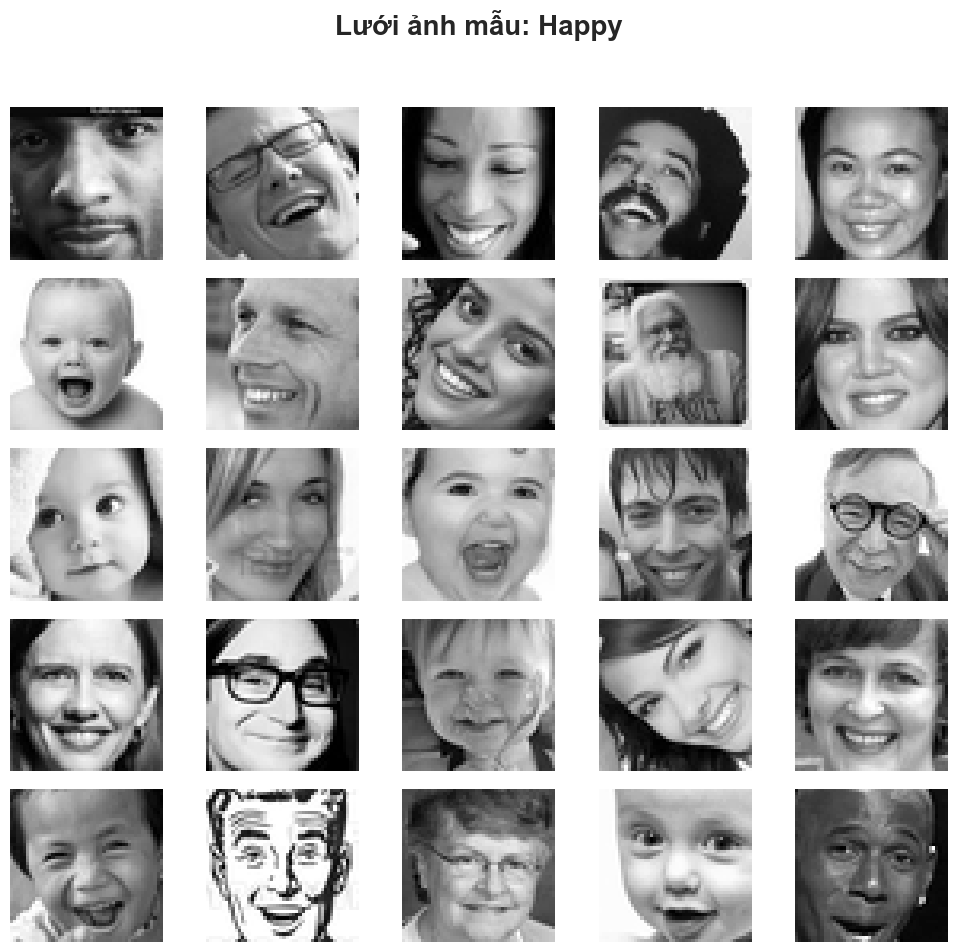

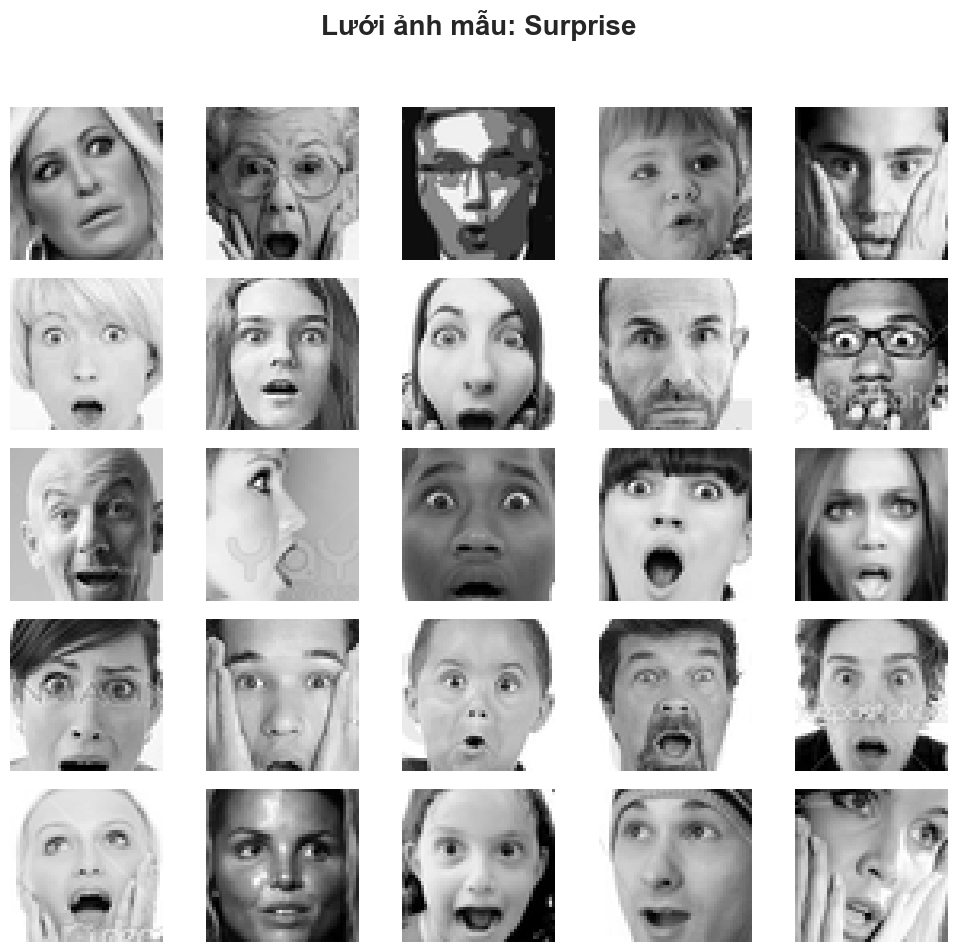

In [6]:
def pixels_to_array(pixels_str):
    return np.array(pixels_str.split(), dtype='int').reshape(48, 48)

def plot_grid(df, emotion_code, label, grid_size=(5, 5)):
    samples = df[df['emotion'] == emotion_code].sample(grid_size[0] * grid_size[1], random_state=42)
    
    fig, axes = plt.subplots(grid_size[0], grid_size[1], figsize=(10, 10))
    fig.suptitle(f"Lưới ảnh mẫu: {label}", fontsize=20, fontweight='bold')
    
    for i, ax in enumerate(axes.flat):
        img = pixels_to_array(samples['pixels'].iloc[i])
        ax.imshow(img, cmap='gray')
        ax.axis('off')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Ví dụ hiển thị cho cảm xúc Happy và Surprise
plot_grid(df_train, 3, "Happy")
plot_grid(df_train, 5, "Surprise")

## 2. Quan sát tính đa dạng (Diversity)
Dựa trên các lưới ảnh, ta có thể nhận thấy bộ dữ liệu FER2013 rất đa dạng:
- **Góc mặt**: Có cả ảnh chính diện và ảnh nghiên (profile).
- **Độ tuổi**: Bao gồm trẻ em, thanh niên và người già.
- **Ánh sáng**: Nhiều ảnh bị tối hoặc có độ tương phản cao.
- **Vật cản**: Một số ảnh có tay che mặt hoặc vật dụng xung quanh.

## 3. Phân tích Thống kê Pixel (Pixel Intensity Analysis)
Việc tính toán Mean và Std giúp chúng ta chuẩn hóa ảnh về cùng một dải phân phối, giúp model hội tụ nhanh hơn.

In [7]:
# Chuyển đổi toàn bộ pixel thành mảng numpy lớn (để tính toán chính xác)
all_pixels = []
for pixel_str in tqdm(df_train['pixels'], desc="Đang xử lý pixel"):
    all_pixels.append(np.array(pixel_str.split(), dtype='float32'))

all_pixels = np.concatenate(all_pixels) / 255.0  # Chuẩn hóa về [0, 1] trước khi tính

mean = np.mean(all_pixels)
std = np.std(all_pixels)

print(f"\nKết quả thống kê tập Train (trên dải 0-1):")
print(f"- Mean: {mean:.4f}")
print(f"- Std:  {std:.4f}")

Đang xử lý pixel:   0%|          | 0/28709 [00:00<?, ?it/s]

Đang xử lý pixel: 100%|██████████| 28709/28709 [00:06<00:00, 4106.06it/s]



Kết quả thống kê tập Train (trên dải 0-1):
- Mean: 0.5077
- Std:  0.2550


## 4. Biểu đồ Histogram
Biểu đồ này hiển thị phân phối cường độ pixel toàn cục của tập huấn luyện.

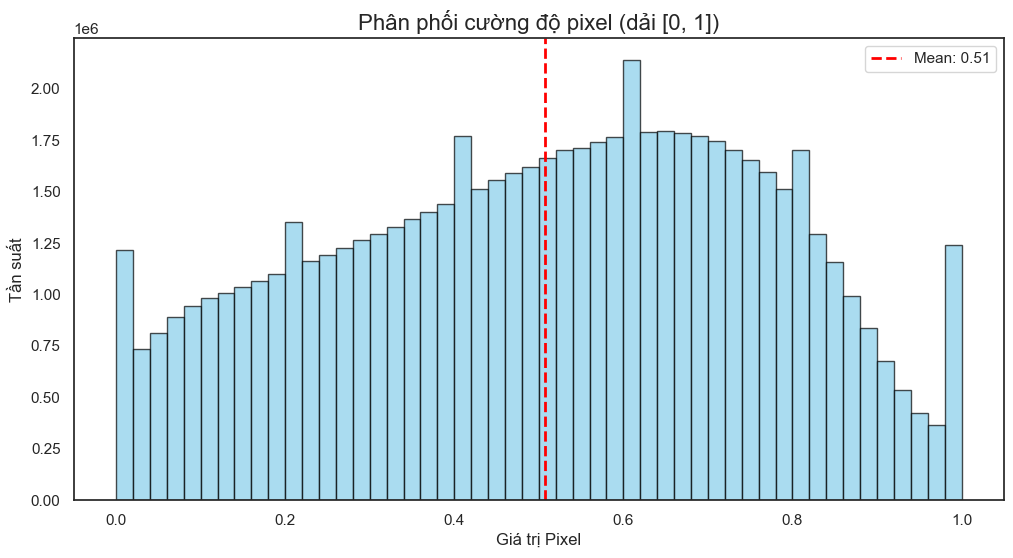

In [8]:
plt.figure(figsize=(12, 6))
plt.hist(all_pixels, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean:.2f}')
plt.title("Phân phối cường độ pixel (dải [0, 1])", fontsize=16)
plt.xlabel("Giá trị Pixel", fontsize=12)
plt.ylabel("Tần suất", fontsize=12)
plt.legend()
plt.show()

## Kết luận
- Dữ liệu có độ biến động ánh sáng lớn (trên histogram có phân phối khá rộng).
- Các giá trị **Mean** và **Std** phía trên nên được sử dụng trong `torchvision.transforms.Normalize` khi định nghĩa DataLoader.